In [2]:
import os
import random
import numpy as np
import torch
import torch_geometric
from torch_geometric.datasets import QM9
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import rdkit

# reproducability
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# CPU only
DEVICE = torch.device("cpu")

print("=" * 45)
print("   Enviornment Verification(versions)")
print("=" * 45)
print(f"  Python  : {os.sys.version.split()[0]}")
print(f"  Numpy  : {np.__version__}")
print(f"  PyTorch  : {torch.__version__}")
print(f"  PyG  : {torch_geometric.__version__}")
print(f"  Matplotlib  : {matplotlib.__version__}")
print(f"  Scikit-learn  : {sklearn.__version__}")
print(f"  RDKit  : {rdkit.__version__}")
print(f"  Device  : {DEVICE}")
print("All imports done!")


   Enviornment Verification(versions)
  Python  : 3.9.25
  Numpy  : 1.26.4
  PyTorch  : 2.0.0
  PyG  : 2.5.2
  Matplotlib  : 3.9.4
  Scikit-learn  : 1.6.1
  RDKit  : 2025.03.5
  Device  : cpu
All imports done!


In [4]:
# QM9 Dataset load & check
from torch_geometric.datasets import QM9

# loading 
dataset = QM9(root="data/QM9")

# subset first 20K molecules due to hardware limitations
dataset = dataset[:20000]

# inspecting a single molecule
mol = dataset[0]

print("=" * 50)
print("   QM9 dataset Overview")
print("=" * 50)
print(f"Total molecules (subset) : {len(dataset)}")
print(f"Number of node features : {dataset.num_node_features}")
print(f"Number of edge features : {dataset.num_edge_features}")
print(f"Number of targets : {mol.y.shape[1]}")
print()
print("_" * 50)
print("   Single molecule inspection (mol #0)")
print("_" * 50)
print(f" Node feature matrix x : {mol.x.shape} (atoms x features)")
print(f" Edge index : {mol.edge_index.shape} (2 x num_edges)")
print(f" Edge attributes : {mol.edge_attr.shape} (edge x features)")
print(f" target vector y : {mol.y.shape}")
print(f" Atom positions (pos) : {mol.pos.shape}")
print()
print("_" * 50)
print("  Target property we predict (index 4)")
print("_" * 50)
print(f" HOMO-LUMO gap (ev) : {mol.y[0, 4].item():.6f}")
print()
print("_" * 50)
print("  Node feature matrix (first 5 atoms)")
print("_" * 50)
print(mol.x[:5])
print("=" * 50)

Extracting data\QM9\raw\qm9.zip
Processing...
100%|████████████████████████████████████████████████████████████████████████| 133885/133885 [01:59<00:00, 1117.12it/s]
Done!


   QM9 dataset Overview
Total molecules (subset) : 20000
Number of node features : 11
Number of edge features : 4
Number of targets : 19

__________________________________________________
   Single molecule inspection (mol #0)
__________________________________________________
 Node feature matrix x : torch.Size([5, 11]) (atoms x features)
 Edge index : torch.Size([2, 8]) (2 x num_edges)
 Edge attributes : torch.Size([8, 4]) (edge x features)
 target vector y : torch.Size([1, 19])
 Atom positions (pos) : torch.Size([5, 3])

__________________________________________________
  Target property we predict (index 4)
__________________________________________________
 HOMO-LUMO gap (ev) : 13.736308

__________________________________________________
  Node feature matrix (first 5 atoms)
__________________________________________________
tensor([[0., 1., 0., 0., 0., 6., 0., 0., 0., 0., 4.],
        [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 1., 0., 0., 0., 0.

   Node features (11 total)
  [ 0 H (one-hot)]
  [ 1 C (one-hot)]
  [ 2 N (one-hot)]
  [ 3 O (one-hot)]
  [ 4 F (one-hot)]
  [ 5 Atomic number]
  [ 6 Aromatic]
  [ 7 sp hybridization]
  [ 8 sp2 hybridization]
  [ 9 sp3 hybridization]
  [10 Num Hs]

   Edge Features (4 total)
  [ 0 Single bond]
  [ 1 Double bond]
  [ 2 Triple bond]
  [ 3 Aromatic bond]

   HOMO-LUMO Gap Statistics (eV)
  mean  :  7.1636 eV
  Std  :  1.2916 eV
  Min  :  2.0844 eV
  Max  :  16.9282 eV
  Median  :  7.1974 eV

   Molecule Size Statistics (# atoms)
  Mean  :  16.35
  Min  :  3
  Max  :  26


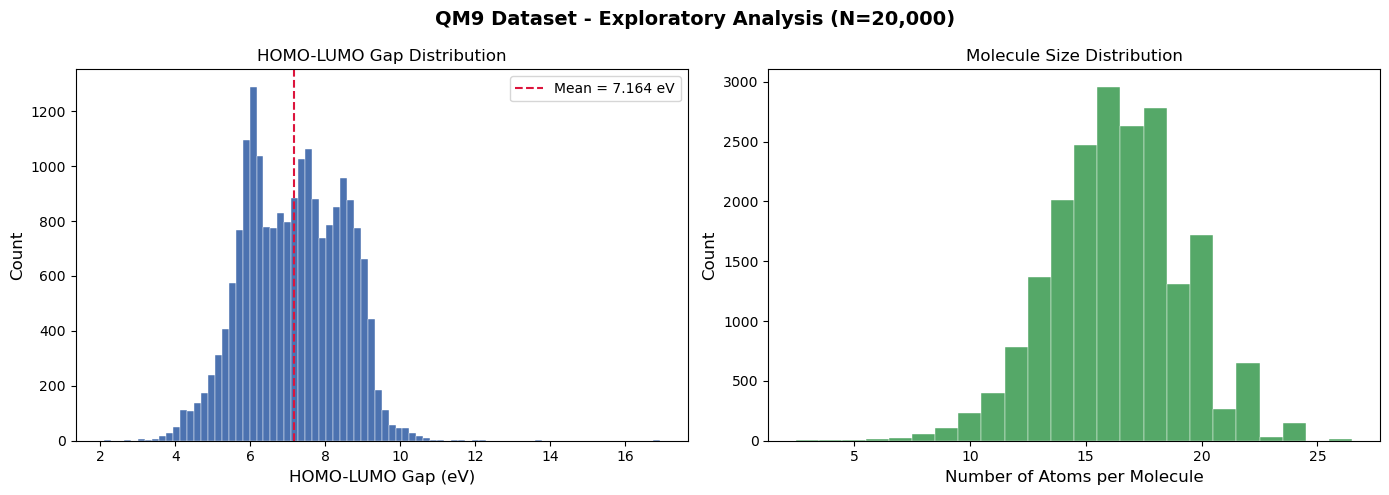

Plot saved as eda_plots.png!


In [7]:
# exploratory Data analysis
import torch
import matplotlib.pyplot as plt
import numpy as np

# Feature documentation (PyG QM9 node features, 11 total)
NODE_FEATURE_NAMES = [
    "H (one-hot)",
    "C (one-hot)",
    "N (one-hot)",
    "O (one-hot)",
    "F (one-hot)",
    "Atomic number",
    "Aromatic",
    "sp hybridization",
    "sp2 hybridization",
    "sp3 hybridization",
    "Num Hs",
]

EDGE_FEATURE_NAMES = [
    "Single bond",
    "Double bond",
    "Triple bond",
    "Aromatic bond",
]

print("=" * 50)
print("   Node features (11 total)")
print("=" * 50)
for i, name in enumerate(NODE_FEATURE_NAMES):
    print(f"  [{i:2d} {name}]")

print()
print("=" * 50)
print("   Edge Features (4 total)")
print("=" * 50)
for i, name in enumerate(EDGE_FEATURE_NAMES):
    print(f"  [{i:2d} {name}]")

# collect HOMO-LUMO gap values across all 20K molecules
homo_lumo_gaps = torch.stack([data.y[0, 4] for data in dataset]).numpy()

# collect molecule sizes (number of atoms)
mol_sizes = torch.tensor([data.x.shape[0] for data in dataset]).numpy()

# statistics
print()
print("=" * 50)
print("   HOMO-LUMO Gap Statistics (eV)")
print("=" * 50)
print(f"  mean  :  {homo_lumo_gaps.mean():.4f} eV")
print(f"  Std  :  {homo_lumo_gaps.std():.4f} eV")
print(f"  Min  :  {homo_lumo_gaps.min():.4f} eV")
print(f"  Max  :  {homo_lumo_gaps.max():.4f} eV")
print(f"  Median  :  {np.median(homo_lumo_gaps):.4f} eV")

print()
print("=" * 50)
print("   Molecule Size Statistics (# atoms)")
print("=" * 50)
print(f"  Mean  :  {mol_sizes.mean():.2f}")
print(f"  Min  :  {mol_sizes.min()}")
print(f"  Max  :  {mol_sizes.max()}")


# plots
fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle("QM9 Dataset - Exploratory Analysis (N=20,000)", fontsize=14, fontweight="bold")

# plot 1: HOMO-LUMO gap distribution
axes[0].hist(homo_lumo_gaps, bins=80, color="#4C72B0", edgecolor="white", linewidth=0.3)
axes[0].axvline(homo_lumo_gaps.mean(), color="crimson", linestyle="--", linewidth=1.5, label=f"Mean = {homo_lumo_gaps.mean():.3f} eV")
axes[0].set_xlabel("HOMO-LUMO Gap (eV)", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_title("HOMO-LUMO Gap Distribution", fontsize=12)
axes[0].legend()

# plot 2: molecule size distribution
axes[1].hist(mol_sizes, bins=range(mol_sizes.min(), mol_sizes.max() + 2), color="#55A868", edgecolor="white", linewidth=0.3, align="left")
axes[1].set_xlabel("Number of Atoms per Molecule", fontsize=12)
axes[1].set_ylabel("Count", fontsize=12)
axes[1].set_title("Molecule Size Distribution", fontsize=12)

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved as eda_plots.png!")

In [10]:
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

# step 1: add bond length as edge feature
# bond length: euclidean distance between atom i & atom j
# bond lengths encode bond order indirectly

def add_bond_length(data):
    # compute bond lengths from 3D positions & append to edge_attr.
    row, col = data.edge_index
    pos_diff = data.pos[row] - data.pos[col]
    bond_length = pos_diff.norm(dim=1, keepdim=True)
    # concat to existing 4 edge features -> 5 edge feature total
    data.edge_attr = torch.cat([data.edge_attr, bond_length], dim=1)
    return data

#  step 2: extract target (HOMO-LUMO gap, index 4) & node/edge features
def prepare_molecule(data):
    # return a clean data object with only what we need.
    data = add_bond_length(data)
    return Data(
        x = data.x.float(),
        edge_index = data.edge_index,
        edge_attr = data.edge_attr.float(),
        y = data.y[:, 4].float(),
        pos = data.pos.float(),
    ) 

print("processing molecules...")
processed = [prepare_molecule(data) for data in dataset]
print(f"processed {len(processed)} molecules!")


# step 3: normalize target (zero mean, unit variance)
# we store maen/std for denormalization during evaluation.

all_targets = torch.cat([d.y for d in processed])
TARGET_MEAN = all_targets.mean().item()
TARGET_STD = all_targets.std().item()

for d in processed:
    d.y = (d.y - Target_MEAN) / TARGET_STD

print(f"\nTarget normalization:")
print(f"  Mean (eV) : {TARGET_MEAN:.4f}")
print(f"  Std (eV) : {TARGET_STD:.4f}")

# step 4: Train / Val / Test split (80/10/10)
N = len(processed)
n_train = int(0.80 * N)
n_val = int(0.10 * N)
n_test = N - n_train - n_val

train_data = processed[:n_train]
val_data = processed[n_train : n_train + n_val]
test_data = processed[n_train + n_val :]

print(f"\nDataset splits:")
print(f"  Train : {len(train_data):,} molecules")
print(f"  Val : {len(val_data):,} molecules")
print(f"  Test : {len(test_data):,} molecules")

# step 5: DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nDataloaders ready:")
print(f" Batch size : {BATCH_SIZE}")
print(f" Train batches : {len(train_loader)}")
print(f" Val batches : {len(val_loader)}")
print(f" Test batches : {len(test_loader)}")

# step 6: sanity check one batch
batch = next(iter(train_loader))
print(f"\nSingle batch inspection:")
print(f"  x shape : {batch.x.shape} (total atoms in batch x 11)")
print(f"  edge_attr shape : {batch.edge_attr.shape} (total edges x 5)")
print(f"  y shape : {batch.y.shape} (batch_size)")
print(f"  batch vector : {batch.batch.shape}")

processing molecules...
processed 20000 molecules!

Target normalization:
  Mean (eV) : 7.1636
  Std (eV) : 1.2916

Dataset splits:
  Train : 16,000 molecules
  Val : 2,000 molecules
  Test : 2,000 molecules

Dataloaders ready:
 Batch size : 64
 Train batches : 250
 Val batches : 32
 Test batches : 32

Single batch inspection:
  x shape : torch.Size([1069, 11]) (total atoms in batch x 11)
  edge_attr shape : torch.Size([2156, 5]) (total edges x 5)
  y shape : torch.Size([64]) (batch_size)
  batch vector : torch.Size([1069])


In [12]:
# Graph Transformer Model Architecture

import torch
import torch.nn as nn
from torch_geometric.nn import TransformerConv, global_mean_pool
from torch_geometric.nn import BatchNorm

class MolecularGraphTransformer(nn.Module):
    """
    Graph Transformer for molecular property prediction.

    Architecture:
      1. Input projection  — maps raw node features (11) → hidden dim
      2. Edge projection   — maps raw edge features (5)  → hidden dim
      3. Three TransformerConv layers with residual connections
      4. Global mean pooling → graph-level embedding
      5. MLP readout         → scalar property prediction

    TransformerConv computes multi-head attention over
    the local neighbourhood of each atom. Edge features are injected into
    the attention score computation, so bond type and length directly
    influence which atoms the model attends to.

    Attention weights are stored during the forward pass for explainability.
    """

    def __init__(
        self,
        node_in_dim  : int = 11,   
        edge_in_dim  : int = 5,    
        hidden_dim   : int = 128,  
        num_heads    : int = 4,    
        num_layers   : int = 3,    # number of message-passing layers
        dropout      : float = 0.1,
    ):
        super().__init__()

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        head_dim = hidden_dim // num_heads  

        # input projections 
        self.node_proj = nn.Linear(node_in_dim, hidden_dim)
        self.edge_proj = nn.Linear(edge_in_dim, hidden_dim)

        # transformerConv layers
        # each layer takes (hidden_dim → hidden_dim) with edge_dim=hidden_dim.
        # concat=False averages heads → output stays at hidden_dim.
        self.conv_layers = nn.ModuleList([
            TransformerConv(
                in_channels  = hidden_dim,
                out_channels = head_dim,
                heads        = num_heads,
                edge_dim     = hidden_dim,
                dropout      = dropout,
                concat       = True,   # concat heads → num_heads * head_dim
                beta         = True,   # learnable skip connection inside conv
            )
            for _ in range(num_layers)
        ])

        # After concat, dim = num_heads * head_dim = hidden_dim — project back
        self.post_conv_proj = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim)
            for _ in range(num_layers)
        ])

        # Batch normalisation after each layer
        self.norms = nn.ModuleList([
            BatchNorm(hidden_dim)
            for _ in range(num_layers)
        ])

        # Readout MLP
        self.readout = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.SiLU(),
            nn.Linear(hidden_dim // 4, 1),
        )

        self.dropout = nn.Dropout(dropout)

        # Storage for attention weights (populated during forward)
        self.attention_weights = []

    def forward(self, x, edge_index, edge_attr, batch, return_attention=False):
        """
        Args:
            x           : [N, node_in_dim]  node features
            edge_index  : [2, E]            edge connectivity
            edge_attr   : [E, edge_in_dim]  edge features
            batch       : [N]               molecule index per atom
            return_attention: if True, also return list of attention tensors
        Returns:
            out         : [B, 1] predicted property per molecule
        """
        self.attention_weights = []

        # Project inputs to hidden dim
        x    = self.node_proj(x)          # [N, hidden_dim]
        e    = self.edge_proj(edge_attr)  # [E, hidden_dim]

        # Message passing with residual connections
        for i in range(self.num_layers):
            x_res = x  # save for residual

            if return_attention:
                x_new, attn = self.conv_layers[i](
                    x, edge_index, edge_attr=e, return_attention_weights=True
                )
                self.attention_weights.append(attn)
            else:
                x_new = self.conv_layers[i](x, edge_index, edge_attr=e)

            x_new = self.post_conv_proj[i](x_new)  # [N, hidden_dim]
            x_new = self.norms[i](x_new)
            x_new = torch.nn.functional.silu(x_new)
            x_new = self.dropout(x_new)
            x     = x_new + x_res  # residual

        # global mean pooling → graph embedding
        graph_emb = global_mean_pool(x, batch)  # [B, hidden_dim]

        # predict
        out = self.readout(graph_emb)            # [B, 1]
        out = out.squeeze(-1)                    # [B]

        if return_attention:
            return out, self.attention_weights
        return out


# instantiate and inspect
model = MolecularGraphTransformer(
    node_in_dim = 11,
    edge_in_dim = 5,
    hidden_dim  = 128,
    num_heads   = 4,
    num_layers  = 3,
    dropout     = 0.1,
).to(DEVICE)

# Parameter count
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 50)
print("  Model Architecture")
print("=" * 50)
print(model)
print("=" * 50)
print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")
print("=" * 50)

# quick forward pass sanity check
model.eval()
with torch.no_grad():
    sample = next(iter(train_loader))
    out = model(sample.x, sample.edge_index, sample.edge_attr, sample.batch)

print(f"\nForward pass check:")
print(f"  Input batch size : {sample.y.shape[0]} molecules")
print(f"  Output shape     : {out.shape}")
print(f"  Output sample    : {out[:5].numpy().round(4)}")
print("\nModel ready!")

  Model Architecture
MolecularGraphTransformer(
  (node_proj): Linear(in_features=11, out_features=128, bias=True)
  (edge_proj): Linear(in_features=5, out_features=128, bias=True)
  (conv_layers): ModuleList(
    (0-2): 3 x TransformerConv(128, 32, heads=4)
  )
  (post_conv_proj): ModuleList(
    (0-2): 3 x Linear(in_features=128, out_features=128, bias=True)
  )
  (norms): ModuleList(
    (0-2): 3 x BatchNorm(128)
  )
  (readout): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): SiLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): SiLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.1, inplace=False)
)
  Total parameters     : 311,425
  Trainable parameters : 311,425

Forward pass check:
  Input batch size : 64 molecules
  Output shape     : torch.Size([64])
  Output sample    : [-0.1065 -0.1113 -0.1067 -0.1091 -0.1125]

Model ready!


In [15]:
# Training Loop

import time
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# hyperparameters
EPOCHS      = 100
LR          = 1e-3
WEIGHT_DECAY= 1e-5

# Optimizer & scheduler
optimizer = Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Reduce LR by 0.5 if val loss doesn't improve for 5 epochs
scheduler = ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-5
)

loss_fn = nn.MSELoss()  # we train with MSE, report MAE

# helper functions
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = loss_fn(pred, batch.y)
        loss.backward()
        # Gradient clipping — prevents exploding gradients on CPU
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, device, target_mean, target_std):
    """Returns MSE loss (normalized) and MAE (original eV scale)."""
    model.eval()
    total_mse = 0.0
    total_mae = 0.0
    for batch in loader:
        batch = batch.to(device)
        pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        total_mse += nn.MSELoss()(pred, batch.y).item() * batch.num_graphs
        # Denormalize for MAE in eV
        pred_ev = pred * target_std + target_mean
        true_ev = batch.y * target_std + target_mean
        total_mae += (pred_ev - true_ev).abs().sum().item()
    mse = total_mse / len(loader.dataset)
    mae = total_mae / len(loader.dataset)
    return mse, mae


# Training loop
history = {"train_loss": [], "val_loss": [], "val_mae": [], "lr": []}

best_val_mae  = float("inf")
best_epoch    = 0
patience_cnt  = 0
EARLY_STOP    = 15   # stop if no improvement for 15 epochs

print("=" * 62)
print(f"  Training — {EPOCHS} epochs  |  batch={BATCH_SIZE}  |  lr={LR}")
print(f"  Naive baseline MAE (predict mean): ~{TARGET_STD:.4f} eV")
print("=" * 62)
print(f"{'Epoch':>5} | {'Train MSE':>10} | {'Val MSE':>9} | {'Val MAE (eV)':>12} | {'LR':>8} | {'Time':>6}")
print("-" * 62)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, DEVICE)
    val_mse, val_mae = evaluate(model, val_loader, DEVICE, TARGET_MEAN, TARGET_STD)

    scheduler.step(val_mse)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_mse)
    history["val_mae"].append(val_mae)
    history["lr"].append(current_lr)

    elapsed = time.time() - t0

    # Track best model
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_epoch   = epoch
        torch.save(model.state_dict(), "best_model.pt")
        marker = " ◀ best"
    else:
        marker = ""

    print(f"{epoch:>5} | {train_loss:>10.5f} | {val_mse:>9.5f} | "
          f"{val_mae:>10.4f} eV | {current_lr:>8.6f} | {elapsed:>4.1f}s{marker}")

print("=" * 62)
print(f"\nTraining complete.")
print(f"  Best Val MAE : {best_val_mae:.4f} eV  (epoch {best_epoch})")
print(f"  Naive baseline was : {TARGET_STD:.4f} eV")
print(f"  Improvement  : {(1 - best_val_mae/TARGET_STD)*100:.1f}% over baseline")

  Training — 100 epochs  |  batch=64  |  lr=0.001
  Naive baseline MAE (predict mean): ~1.2916 eV
Epoch |  Train MSE |   Val MSE | Val MAE (eV) |       LR |   Time
--------------------------------------------------------------
    1 |    0.03815 |   0.05293 |     0.2165 eV | 0.001000 | 17.4s ◀ best
    2 |    0.03654 |   0.05542 |     0.2189 eV | 0.001000 | 16.9s
    3 |    0.03761 |   0.06183 |     0.2369 eV | 0.001000 | 16.9s
    4 |    0.03717 |   0.05495 |     0.2225 eV | 0.001000 | 17.4s
    5 |    0.03658 |   0.08630 |     0.2816 eV | 0.001000 | 17.1s
    6 |    0.03727 |   0.05028 |     0.2110 eV | 0.001000 | 19.6s ◀ best
    7 |    0.03530 |   0.05717 |     0.2197 eV | 0.001000 | 20.6s
    8 |    0.03542 |   0.05753 |     0.2167 eV | 0.001000 | 20.3s
    9 |    0.03427 |   0.05623 |     0.2288 eV | 0.001000 | 20.3s
   10 |    0.03545 |   0.06443 |     0.2319 eV | 0.001000 | 20.3s
   11 |    0.03372 |   0.05032 |     0.2096 eV | 0.001000 | 19.4s ◀ best
   12 |    0.03342 |   0.0

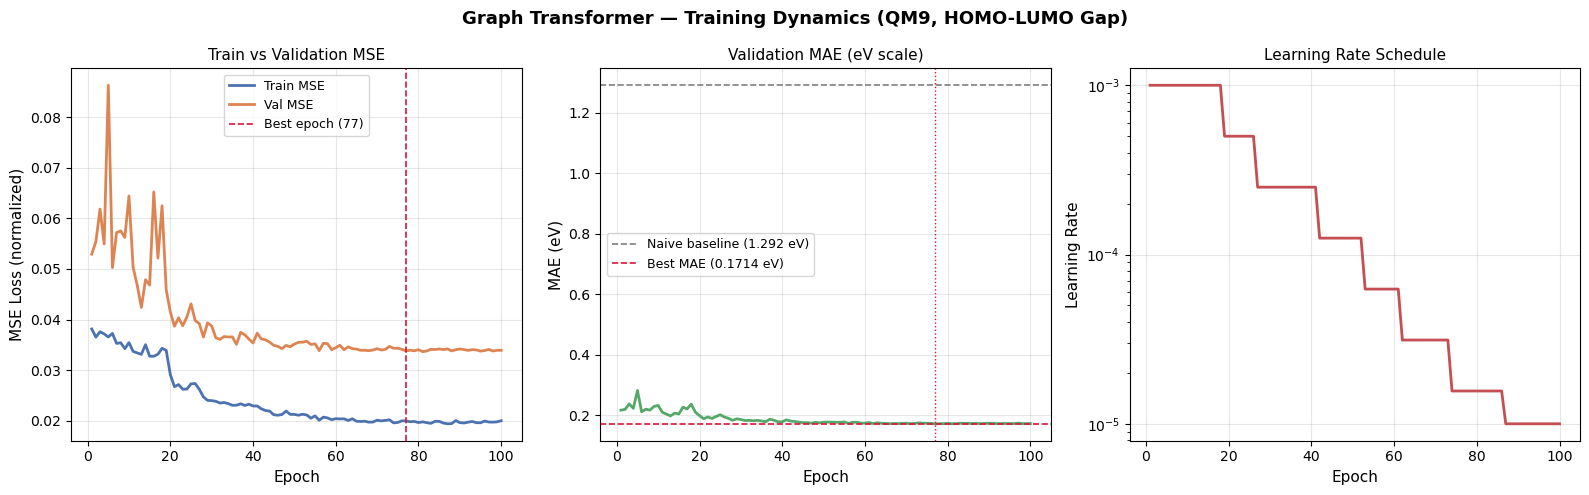

Saved: training_curves.png

  Final Training Summary
  Best Val MAE     : 0.1714 eV
  Best epoch       : 77
  Naive baseline   : 1.2916 eV
  Improvement      : 86.7%
  Final LR         : 1.00e-05


In [16]:
# Training & Validation Loss Curves

import matplotlib.pyplot as plt
import numpy as np

epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Graph Transformer — Training Dynamics (QM9, HOMO-LUMO Gap)",
    fontsize=13, fontweight="bold"
)

# Plot 1: MSE loss (normalized space)
axes[0].plot(epochs_range, history["train_loss"], label="Train MSE",
             color="#4C72B0", linewidth=2)
axes[0].plot(epochs_range, history["val_loss"],   label="Val MSE",
             color="#DD8452", linewidth=2)
axes[0].axvline(best_epoch, color="crimson", linestyle="--",
                linewidth=1.2, label=f"Best epoch ({best_epoch})")
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("MSE Loss (normalized)", fontsize=11)
axes[0].set_title("Train vs Validation MSE", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot 2: Validation MAE in eV
axes[1].plot(epochs_range, history["val_mae"], color="#55A868", linewidth=2)
axes[1].axhline(TARGET_STD, color="gray", linestyle="--",
                linewidth=1.2, label=f"Naive baseline ({TARGET_STD:.3f} eV)")
axes[1].axhline(best_val_mae, color="crimson", linestyle="--",
                linewidth=1.2, label=f"Best MAE ({best_val_mae:.4f} eV)")
axes[1].axvline(best_epoch, color="crimson", linestyle=":",
                linewidth=1.0)
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("MAE (eV)", fontsize=11)
axes[1].set_title("Validation MAE (eV scale)", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Plot 3: Learning rate schedule
axes[2].plot(epochs_range, history["lr"], color="#C44E52", linewidth=2)
axes[2].set_xlabel("Epoch", fontsize=11)
axes[2].set_ylabel("Learning Rate", fontsize=11)
axes[2].set_title("Learning Rate Schedule", fontsize=11)
axes[2].set_yscale("log")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: training_curves.png")

# Summary table
print()
print("=" * 45)
print("  Final Training Summary")
print("=" * 45)
print(f"  Best Val MAE     : {best_val_mae:.4f} eV")
print(f"  Best epoch       : {best_epoch}")
print(f"  Naive baseline   : {TARGET_STD:.4f} eV")
print(f"  Improvement      : {(1 - best_val_mae/TARGET_STD)*100:.1f}%")
print(f"  Final LR         : {history['lr'][-1]:.2e}")
print("=" * 45)

Best model weights loaded ✓

  Test Set Results
  N test molecules  : 2,000
  MAE               : 0.2170 eV
  RMSE              : 0.3048 eV
  R²                : 0.9361
  Naive baseline    : 1.2916 eV
  Improvement       : 83.2% over baseline


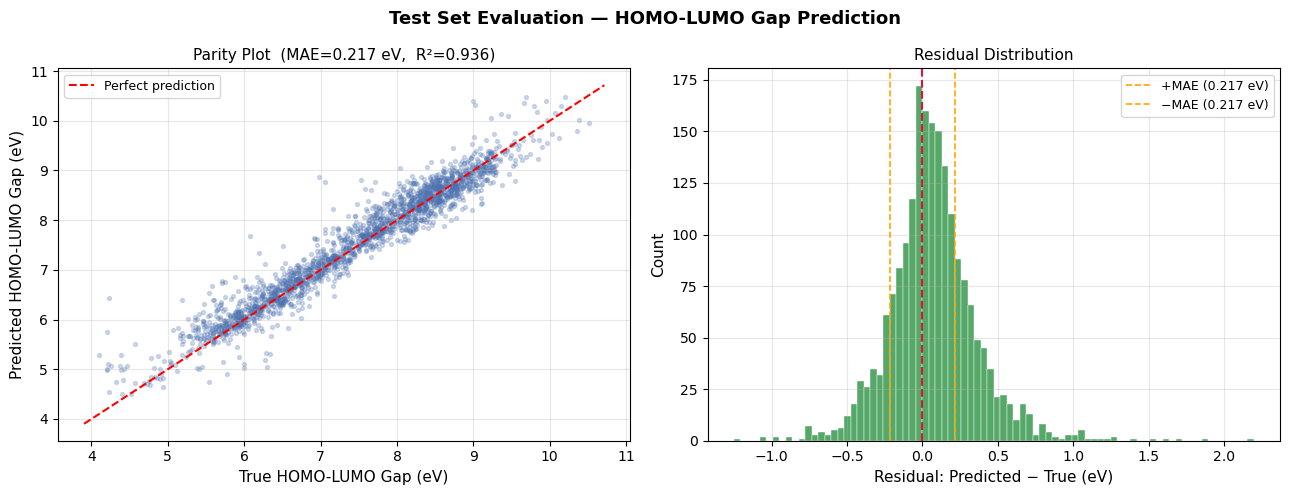

Saved: test_evaluation.png


In [17]:
# Test Set Evaluation

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Load best saved weights
model.load_state_dict(torch.load("best_model.pt", map_location=DEVICE))
model.eval()
print("Best model weights loaded ✓")

# Run inference on test set
all_preds = []
all_true  = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(DEVICE)
        pred  = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)

        # Denormalize back to eV
        pred_ev = pred * TARGET_STD + TARGET_MEAN
        true_ev = batch.y * TARGET_STD + TARGET_MEAN

        all_preds.append(pred_ev.cpu())
        all_true.append(true_ev.cpu())

all_preds = torch.cat(all_preds).numpy()
all_true  = torch.cat(all_true).numpy()

# Metrics
mae  = np.abs(all_preds - all_true).mean()
rmse = np.sqrt(((all_preds - all_true) ** 2).mean())
# R² score
ss_res = ((all_true - all_preds) ** 2).sum()
ss_tot = ((all_true - all_true.mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot

print()
print("=" * 45)
print("  Test Set Results")
print("=" * 45)
print(f"  N test molecules  : {len(all_true):,}")
print(f"  MAE               : {mae:.4f} eV")
print(f"  RMSE              : {rmse:.4f} eV")
print(f"  R²                : {r2:.4f}")
print(f"  Naive baseline    : {TARGET_STD:.4f} eV")
print(f"  Improvement       : {(1 - mae/TARGET_STD)*100:.1f}% over baseline")
print("=" * 45)

# Parity plot: predicted vs true
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Test Set Evaluation — HOMO-LUMO Gap Prediction",
             fontsize=13, fontweight="bold")

# Parity plot
axes[0].scatter(all_true, all_preds, alpha=0.25, s=8,
                color="#4C72B0", rasterized=True)
lims = [all_true.min() - 0.2, all_true.max() + 0.2]
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("True HOMO-LUMO Gap (eV)", fontsize=11)
axes[0].set_ylabel("Predicted HOMO-LUMO Gap (eV)", fontsize=11)
axes[0].set_title(f"Parity Plot  (MAE={mae:.3f} eV,  R²={r2:.3f})", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Residual distribution
residuals = all_preds - all_true
axes[1].hist(residuals, bins=80, color="#55A868", edgecolor="white", linewidth=0.3)
axes[1].axvline(0,             color="crimson", linestyle="--", linewidth=1.5)
axes[1].axvline( mae, color="orange", linestyle="--",
                 linewidth=1.2, label=f"+MAE ({mae:.3f} eV)")
axes[1].axvline(-mae, color="orange", linestyle="--",
                 linewidth=1.2, label=f"−MAE ({mae:.3f} eV)")
axes[1].set_xlabel("Residual: Predicted − True (eV)", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)
axes[1].set_title("Residual Distribution", fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("test_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: test_evaluation.png")

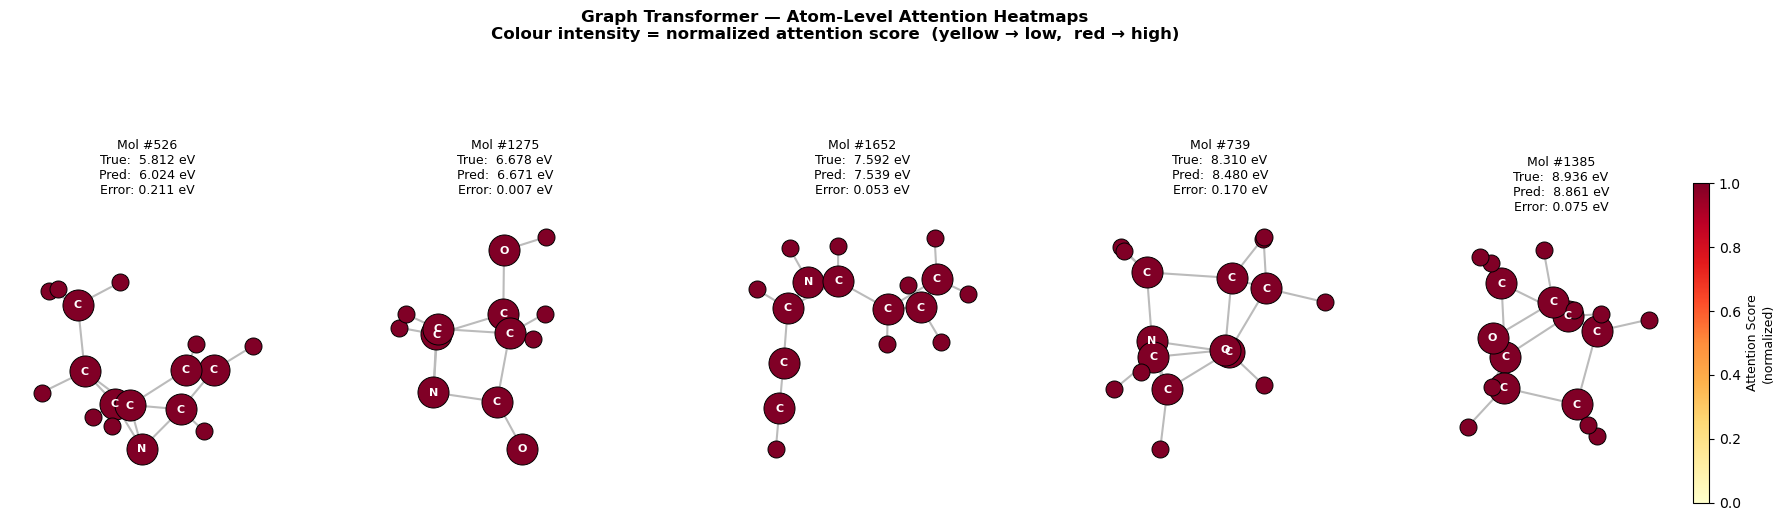

Saved: attention_heatmaps.png


In [19]:
# Cell 9 (fixed) │ Attention Weight Visualization

import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from torch_geometric.data import Batch

@torch.no_grad()
def get_atom_attention_scores(model, data, device):
    model.eval()
    batch = Batch.from_data_list([data]).to(device)
    pred_norm, attn_list = model(
        batch.x, batch.edge_index, batch.edge_attr,
        batch.batch, return_attention=True
    )
    pred_ev = pred_norm.item() * TARGET_STD + TARGET_MEAN
    true_ev = data.y.item()   * TARGET_STD + TARGET_MEAN
    num_atoms = data.x.shape[0]
    atom_scores = np.zeros(num_atoms)

    for edge_index_layer, attn_weights in attn_list:
        attn_mean = attn_weights.abs().mean(dim=1).cpu().numpy()
        dst = edge_index_layer[1].cpu().numpy()
        for e_idx, dst_node in enumerate(dst):
            if dst_node < num_atoms:
                atom_scores[dst_node] += attn_mean[e_idx]

    if atom_scores.max() > 0:
        atom_scores = atom_scores / atom_scores.max()
    return pred_ev, true_ev, atom_scores


ATOM_SYMBOLS = {0: "H", 1: "C", 2: "N", 3: "O", 4: "F"}

def draw_molecule_attention(ax, data, scores, pred_ev, true_ev, mol_idx):
    pos        = data.pos.numpy()[:, :2]
    x_feat     = data.x.numpy()
    edge_index = data.edge_index.numpy()
    num_atoms  = pos.shape[0]
    atom_types = np.argmax(x_feat[:, :5], axis=1)

    # Normalise positions to [0,1] for consistent sizing
    pos = pos - pos.min(axis=0)
    if pos.max() > 0:
        pos = pos / pos.max()

    # Draw bonds
    drawn_bonds = set()
    for e in range(edge_index.shape[1]):
        i, j = edge_index[0, e], edge_index[1, e]
        if (min(i,j), max(i,j)) not in drawn_bonds:
            ax.plot([pos[i,0], pos[j,0]], [pos[i,1], pos[j,1]],
                    color="#BBBBBB", linewidth=1.5, zorder=1)
            drawn_bonds.add((min(i,j), max(i,j)))

    # Draw atoms
    cmap = matplotlib.colormaps["YlOrRd"]   # ← fixed deprecation
    for atom_i in range(num_atoms):
        atype  = atom_types[atom_i]
        score  = scores[atom_i]
        color  = cmap(score)
        symbol = ATOM_SYMBOLS.get(atype, "?")
        size   = 500 if atype > 0 else 150

        ax.scatter(pos[atom_i, 0], pos[atom_i, 1],
                   c=[color], s=size, zorder=3,
                   edgecolors="black", linewidths=0.7)
        if atype > 0:
            ax.text(pos[atom_i, 0], pos[atom_i, 1], symbol,
                    ha="center", va="center",
                    fontsize=8, fontweight="bold", zorder=4, color="white")

    error = abs(pred_ev - true_ev)
    ax.set_title(
        f"Mol #{mol_idx}\n"
        f"True:  {true_ev:.3f} eV\n"
        f"Pred:  {pred_ev:.3f} eV\n"
        f"Error: {error:.3f} eV",
        fontsize=9, pad=8
    )
    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(-0.15, 1.15)
    ax.axis("off")
    ax.set_aspect("equal")


# Select 5 diverse molecules
test_gaps = [(i, (test_data[i].y.item() * TARGET_STD + TARGET_MEAN))
             for i in range(len(test_data))]
test_gaps.sort(key=lambda x: x[1])
n_total = len(test_gaps)
selected_indices = [
    test_gaps[int(n_total * 0.10)][0],
    test_gaps[int(n_total * 0.30)][0],
    test_gaps[int(n_total * 0.50)][0],
    test_gaps[int(n_total * 0.70)][0],
    test_gaps[int(n_total * 0.90)][0],
]

# Plot
fig, axes = plt.subplots(1, 5, figsize=(22, 6))   # wider figure
fig.suptitle(
    "Graph Transformer — Atom-Level Attention Heatmaps\n"
    "Colour intensity = normalized attention score  (yellow → low,  red → high)",
    fontsize=12, fontweight="bold", y=1.02
)

for plot_i, mol_i in enumerate(selected_indices):
    pred_ev, true_ev, scores = get_atom_attention_scores(
        model, test_data[mol_i], DEVICE
    )
    draw_molecule_attention(
        axes[plot_i], test_data[mol_i], scores, pred_ev, true_ev, mol_i
    )

# Colorbar — attach to last axis only (avoids tight_layout conflict)
sm = plt.cm.ScalarMappable(
    cmap="YlOrRd", norm=plt.Normalize(0, 1)
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[-1], orientation="vertical",
                    fraction=0.08, pad=0.04, shrink=0.75)
cbar.set_label("Attention Score\n(normalized)", fontsize=9)

plt.subplots_adjust(wspace=0.3, top=0.82)
plt.savefig("attention_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: attention_heatmaps.png")